<a href="https://colab.research.google.com/github/vikramvundyala/python_AI-ML/blob/main/U4_MH1_Multi_class_weather_Transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Certification in AIML
## A Program by IIIT-H and TalentSprint

## Problem Statement

To identify and classify different types of weather using any open-source pre-trained models.

## Learning Objectives

At the end of this, you will be able to :

* Load and prepare the dataset
* Strengthen skills in the Transfer Learning area

In [ ]:
#@title Mini-hackathon walkthrough
from IPython.display import HTML

HTML("""<video width="854" height="480" controls>
  <source src="https://cdn.iiith.talentsprint.com/aiml/Experiment_related_data/Walkthrough/B18_U4_MH_Walkthrough.mp4" type="video/mp4">
</video>
""")

## Dataset

Multi-class weather dataset(MWD) for image classification is a valuable dataset contains 1125 images divided into four folders such as sunrise, shine, rain, and cloudy.

## Grading = 10 Marks

## Setup Steps

In [1]:
#@title Run this cell to download the dataset

from IPython import get_ipython
ipython = get_ipython()

notebook="U4_MH1_Multi-class weather_Transfer_learning" #name of the notebook
Answer = "This notebook is graded by mentors on the day of hackathon"
def setup():
#
   ipython.magic("sx wget http://cdn.iiith.talentsprint.com/aiml/Experiment_related_data/Multi-classWeatherDataset.zip")
   ipython.magic("sx unzip -qq Multi-classWeatherDataset.zip")
   print ("Setup completed successfully")
   return

setup()

Setup completed successfully


## Basic Pytorch packages

**torchvision:**  This package is used to load and prepare the dataset. Using this package we can perform/apply transformations on the input data.

**transforms:**  This package is  used to perform preprocessing on images and operations sequentially.

**nn:**  This package provides an easy and modular way to build and train simple or complex neural networks.

**optim:** This package is used for  implementing various optimization algorithms

In [2]:
# Import Libraries
import torch
import torchvision
from torch import nn
from torch import optim
import torch.nn.functional as F

from torchsummary import summary
from torchvision import datasets, transforms, models

## **Stage 1 :** Data Preparation

2 Marks -> Load the data and Split the data into Train and Test sets

1. Define the transformations
2. Prepare the dataset with the defined transformations
3. Split the data into train and test sets
4. Load the train and test data using dataloader

In [3]:
# YOUR CODE HERE for preparing and loading the data
train_transforms = transforms.Compose([
                                       transforms.Resize((224, 224)),
                                       transforms.ToTensor(),
                                       transforms.Normalize([0.485, 0.456, 0.406],
                                                            [0.229, 0.224, 0.225])])
test_transforms = transforms.Compose([
                                      transforms.Resize((224, 224)),
                                      transforms.ToTensor(),
                                      transforms.Normalize([0.485, 0.456, 0.406],
                                                            [0.229, 0.224, 0.225])])

train_data = datasets.ImageFolder('/content/Multi-class Weather Dataset', transform=train_transforms)
test_data = datasets.ImageFolder('/content/Multi-class Weather Dataset', transform=test_transforms)

trainloader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(test_data, batch_size=64)

1 Marks -> Plot the first 10 images

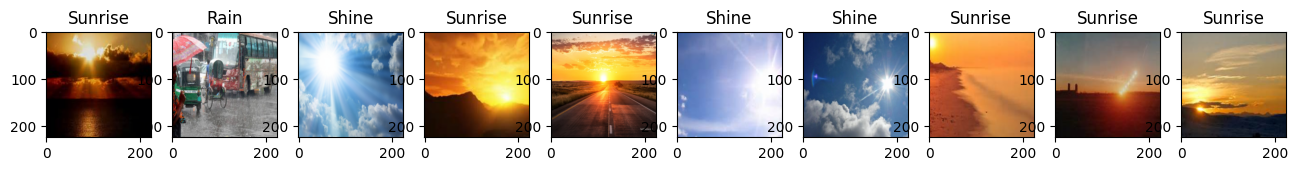

In [4]:
# YOUR CODE HERE for plotting the images
import matplotlib.pyplot as plt
import numpy as np

def imshow(image, ax=None, title=None, normalize=True):
    """Imshow for Tensor."""
    if ax is None:
        fig, ax = plt.subplots()
    image = image.numpy().transpose((1, 2, 0))
    if normalize:
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image = std * image + mean
        image = np.clip(image, 0, 1)

    ax.imshow(image)

    return ax


for images, labels in trainloader:
    fig, axes = plt.subplots(figsize=(16, 8), ncols=10)
    for i in range(10):
        ax = axes[i]
        imshow(images[i], ax=ax)
        ax.title.set_text(train_data.classes[labels[i]])
    break


## **Stage2:** Build the Model

2 Marks -> Prepare the Model using any open-source pretrained model

1. Download a pre-trained model.
2. Fine tune or customize layers in the output to perform classification on a specific task.
3. Declare the loss function and optimizer
4. Print the summary of the model.

In [5]:
# YOUR CODE HERE for preparing the model.

googlenet_model = models.googlenet(pretrained=True)

googlenet_model.fc = nn.Linear(1024, 4)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(googlenet_model.parameters(), lr=0.003)



print(googlenet_model.fc)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=GoogLeNet_Weights.IMAGENET1K_V1`. You can also use `weights=GoogLeNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 132MB/s]


Linear(in_features=1024, out_features=4, bias=True)


## **Stage 3:** Train the Model

2 Marks -> Train the Model and validate it continuously to calculate the loss and accuracy for the train dataset across each epoch.

**Expected training accuracy is above 95%**

In [6]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [7]:
# YOUR CODE HERE
def train_model(num_of_epochs, model):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.003)
    model.train()
    train_losses,  train_accuracy = [], []
    for epoch in range(num_of_epochs):
        train_loss = 0
        correct = 0
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()

        train_losses.append(train_loss/len(trainloader.dataset))
        train_accuracy.append(100 * correct / len(trainloader.dataset))
        print('epoch: {}, Train Loss:{:.6f} Train Accuracy: {:.2f} '.format(epoch+1,train_losses[-1], train_accuracy[-1]))
    return train_accuracy[-1]
# Record loss and accuracy of the train dataset

## **Stage 4:** Evaluate the Model

2 Marks -> Evaluate the model for the test dataset and calculate the loss and accuracy.

**Expected performance of test evaluation is above 95%**

In [8]:
# model.eval()
# YOUR CODE HERE for calculating the accuracy
def test_model(model):
  model.eval()
  test_accuracy = 0
  for images, labels in testloader:
      images, labels = images.to(device), labels.to(device)

      outputs = model(images)
      _, predicted = torch.max(outputs.data, 1)
      test_accuracy += (predicted == labels).sum().item()
  Accuracy = 100 * test_accuracy / len(testloader.dataset)
  print("Accuracy of Test Data is", Accuracy)
  return Accuracy

## **Stage 5:** Report your observations on any two open source pre-trained models

1 Marks -> Report your observations

In [10]:
# YOUR TEXT HERE on your observations

num_classes = 4
num_of_epochs = 10

print(' \n GOOGLENET ')
googlenet_train_accuracy = train_model(num_of_epochs, googlenet_model)
googlenet_test_accuracy = test_model(googlenet_model)
print(' \n TRAIN ACCURACY: {} , TEST_ACCURACY: {} ', googlenet_train_accuracy, googlenet_test_accuracy)

print(' \n --------------------------------------------------------------------------------------------')

print(' \n VGG16 ')

vgg16 = models.vgg16(pretrained=True)
num_features = vgg16.classifier[6].in_features
features = list(vgg16.classifier.children())[:-1]
features.extend([nn.Linear(num_features, num_classes)])
vgg16.classifier = nn.Sequential(*features)

vgg16_train_accuracy = train_model(num_of_epochs, vgg16)
vgg16_test_accuracy = test_model(vgg16)

print(' \n TRAIN ACCURACY: {} , TEST_ACCURACY: {} ', vgg16_train_accuracy, vgg16_test_accuracy)


print(' \n --------------------------------------------------------------------------------------------')

print(' \n RESNET50 ')

resnet50 = models.resnet50(pretrained=True)
in_features = resnet50.fc.in_features
resnet50.fc = nn.Linear(in_features, num_classes)

resnet50_train_accuracy = train_model(num_of_epochs, resnet50)
resnet50_test_accuracy = test_model(resnet50)


 
 RESNET50 


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 177MB/s]


epoch: 1, Train Loss:0.000000 Train Accuracy: 73.33 
epoch: 2, Train Loss:0.000000 Train Accuracy: 88.44 
epoch: 3, Train Loss:0.000000 Train Accuracy: 91.47 
epoch: 4, Train Loss:0.000000 Train Accuracy: 93.42 
epoch: 5, Train Loss:0.000000 Train Accuracy: 92.71 
epoch: 6, Train Loss:0.000000 Train Accuracy: 92.98 
epoch: 7, Train Loss:0.000000 Train Accuracy: 93.24 
epoch: 8, Train Loss:0.000000 Train Accuracy: 93.16 
epoch: 9, Train Loss:0.000000 Train Accuracy: 93.96 
epoch: 10, Train Loss:0.000000 Train Accuracy: 93.78 
Accuracy of Test Data is 93.06666666666666
